# Report on Flight Delays for the Ministry of Transport

This report analyzes the nature and characteristics of flight delays in 2015. The objective is to identify structural problems within the aviation system to support data-driven decision-making.

## 1. Cumulative Effect of Delays Throughout the Day
We examine how the average departure delay changes depending on the scheduled hour of departure. This helps determine if the system suffers from a 'knock-on' effect.

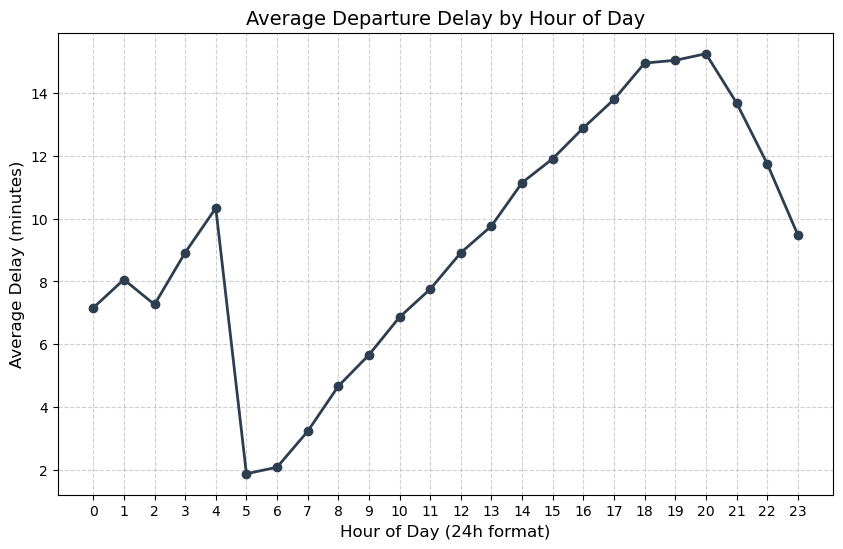

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flights.csv', low_memory=False)
df_flights = df[df['CANCELLED'] == 0].copy()
df_flights['DEPARTURE_HOUR'] = df_flights['SCHEDULED_DEPARTURE'] // 100
hourly_delay = df_flights.groupby('DEPARTURE_HOUR')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(10, 6))
plt.plot(hourly_delay.index, hourly_delay.values, marker='o', color='#2c3e50', linewidth=2)
plt.title('Average Departure Delay by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Conclusion:** The graph shows a clear linear increase in delays as the day progresses. This indicates that the primary problem is a 'cascade effect': morning delays accumulate because of tight turnaround schedules. Airports and airlines should reconsider 'buffer' times for mid-day flights.

## 2. Infrastructure Strain During Peak Days
We analyze the distribution of delays across the days of the week to identify specific days where the system fails to handle the load.

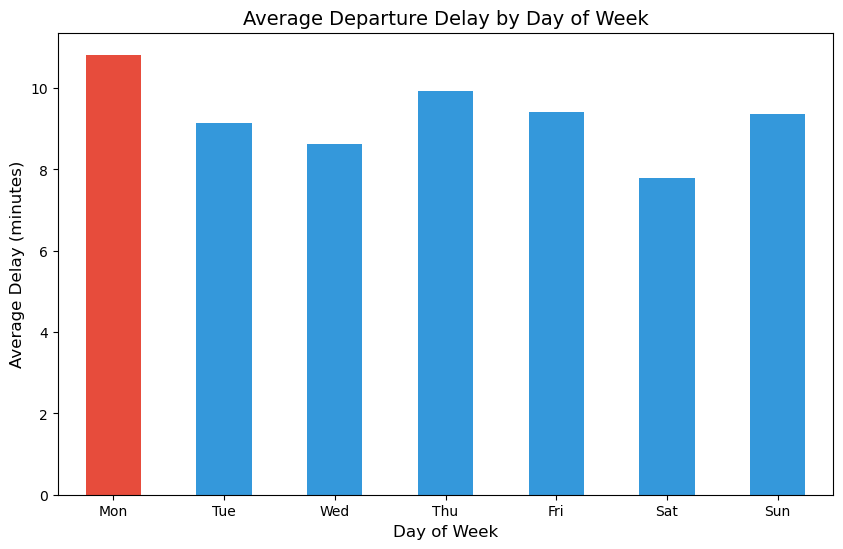

In [2]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df_flights['DAY_NAME'] = df_flights['DAY_OF_WEEK'].map(day_names)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_day_delay = df_flights.groupby('DAY_NAME')['DEPARTURE_DELAY'].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x == avg_day_delay.max() else '#3498db' for x in avg_day_delay.values]
avg_day_delay.plot(kind='bar', color=colors)
plt.title('Average Departure Delay by Day of Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.xticks(rotation=0)
plt.show()

**Conclusion:** Monday shows the highest average delay. This confirms that airport operations struggle with the 'Monday surge' (business travel peak). The Ministry should investigate if staffing at security and ground handling is sufficient for these specific peak windows.

## 3. Root Causes of Cancellations
By identifying why flights are cancelled, we can distinguish between unavoidable weather events and operational failures.

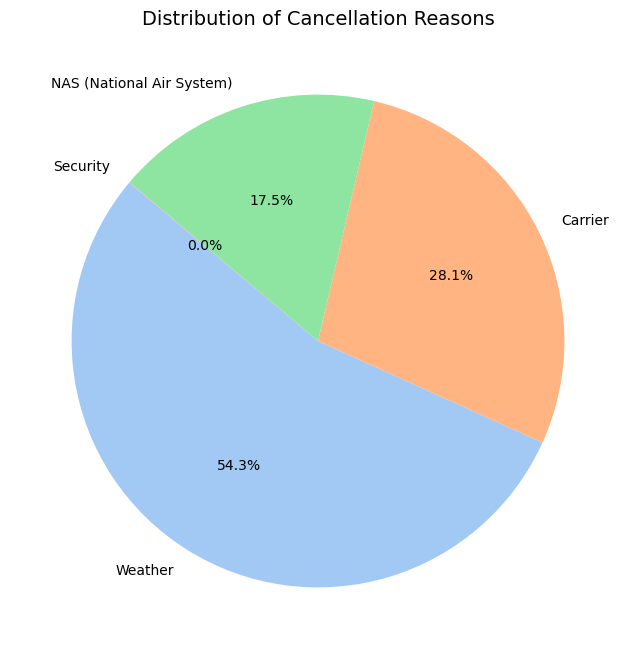

In [3]:
cancel_reasons = df[df['CANCELLED'] == 1]['CANCELLATION_REASON'].value_counts()
reason_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS (National Air System)', 'D': 'Security'}
labels = [reason_map.get(x, x) for x in cancel_reasons.index]

plt.figure(figsize=(8, 8))
plt.pie(cancel_reasons, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Cancellation Reasons', fontsize=14)
plt.show()

**Conclusion:** While weather is a major factor, 'Carrier' and 'NAS' reasons account for a significant percentage. Unlike weather, these are operational inefficiencies. Stricter penalties for carrier-caused cancellations may be necessary to improve reliability.

## 4. Airline Reliability and Performance Comparison
We compare the average delays across different airlines using a horizontal bar chart to identify carriers with consistently poor performance.

/var/folders/xl/hnxdvbns7vzffw3dy_yt2llm0000gn/T/ipykernel_93413/1760363419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delays.values, y=airline_delays.index, palette='magma')


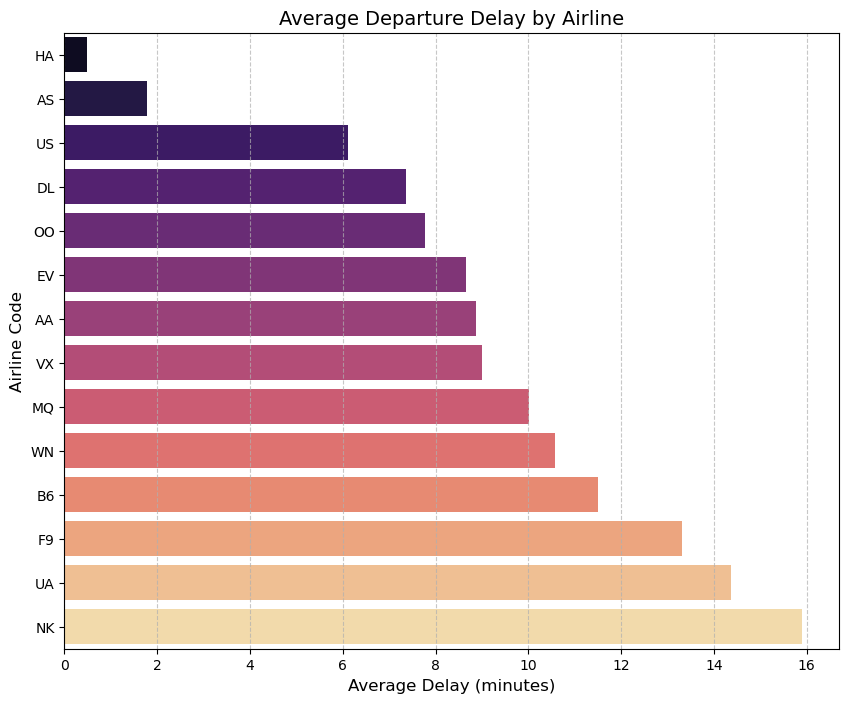

In [4]:
airline_delays = df_flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=airline_delays.values, y=airline_delays.index, palette='magma')
plt.title('Average Departure Delay by Airline', fontsize=14)
plt.xlabel('Average Delay (minutes)', fontsize=12)
plt.ylabel('Airline Code', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Conclusion:** Significant disparities between airlines indicate that some carriers have much more efficient logistics than others. Carriers with the longest horizontal bars represent a priority for regulatory audit to identify why their operational management fails to meet industry standards.

## 5. Identifying Systemic Bottlenecks (Top Airports)
We identify which hub airports are the primary sources of friction in the national network.

/var/folders/xl/hnxdvbns7vzffw3dy_yt2llm0000gn/T/ipykernel_93413/411517208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_stats.index, y=airport_stats.values, palette='viridis')


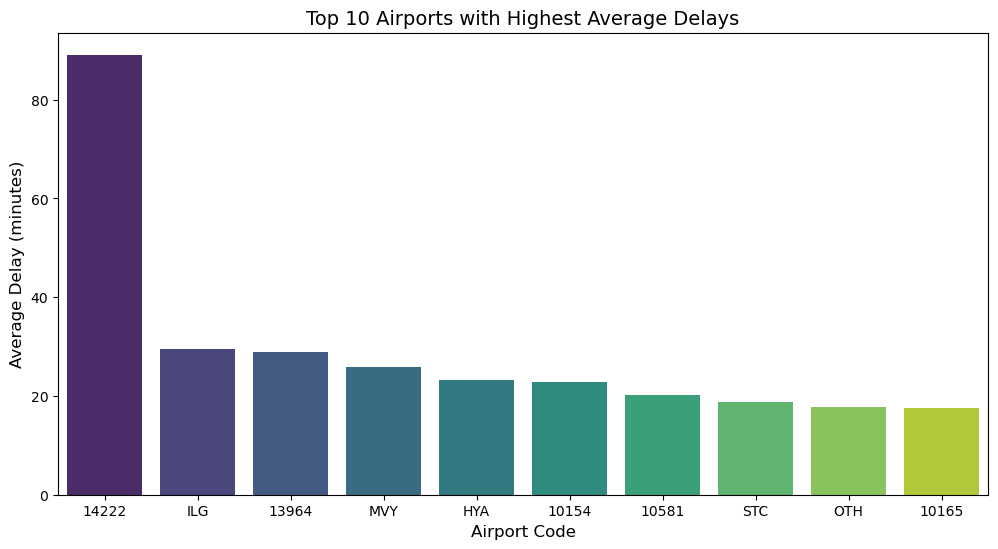

In [5]:
airport_stats = df_flights.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=airport_stats.index, y=airport_stats.values, palette='viridis')
plt.title('Top 10 Airports with Highest Average Delays', fontsize=14)
plt.xlabel('Airport Code', fontsize=12)
plt.ylabel('Average Delay (minutes)', fontsize=12)
plt.show()

**Conclusion:** A few major hubs act as systemic bottlenecks. Delays at these specific nodes likely propagate across the country. Targeted infrastructure upgrades or better slot management at these 10 locations should be the Ministry's top priority.